In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
'''图片数据集载入'''
import torch
import torchvision
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
transform1 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform2 = transforms.Compose([
    transforms.Resize([300, 300]),
    transforms.RandomCrop([128, 128]), #随机裁剪
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform3 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.RandomAffine(20),  #随机仿射变化
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform4 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.RandomEqualize(0.9),  #概率直方图均衡
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform5 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.RandomHorizontalFlip(p=1),  #水平翻转
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform6 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.ColorJitter(brightness=(0.5, 2)),  #亮度在0.5-2之间随机取值进行变化
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform7 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.ColorJitter(contrast=(0.5, 2)),  #对比度在0.5-2之间随机取值进行变化
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform8 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.ColorJitter(saturation=(0.5, 2)),  #饱和度在0.5-2之间随机取值进行变化
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
train_path ='/content/drive/MyDrive/yoga/yoga_pose_solo_evaluated_splited/train/tree'
test_path ='/content/drive/MyDrive/yoga/yoga_pose_solo_evaluated_splited/test/tree'
data1 = torchvision.datasets.ImageFolder(root=train_path,transform=transform1) 
data2 = torchvision.datasets.ImageFolder(root=train_path,transform=transform2)
data3 = torchvision.datasets.ImageFolder(root=train_path,transform=transform3)
data4 = torchvision.datasets.ImageFolder(root=train_path,transform=transform4)
data5 = torchvision.datasets.ImageFolder(root=train_path,transform=transform5)
data6 = torchvision.datasets.ImageFolder(root=train_path,transform=transform6)
data7 = torchvision.datasets.ImageFolder(root=train_path,transform=transform7)
data8 = torchvision.datasets.ImageFolder(root=train_path,transform=transform8)
trainset1 = data1+data2+data3+data4+data5+data6+data7+data8
testset1 = torchvision.datasets.ImageFolder(root=test_path,transform=transform1) 

In [3]:
'''骨架坐标点数据集载入'''
import torch
import pandas as pd
import numpy as np
df = pd.read_excel("/content/drive/MyDrive/yoga/landmarks/tree_train_landmarks.xlsx")
#df = df[df['体式']=='downdog']
df.loc[df['标准/不标准']=='nonstandard', '是否标准编号'] = 0
df.loc[df['标准/不标准']=='standard', '是否标准编号'] = 1
df.drop(["编号", '体式', '标准/不标准'],axis=1, inplace=True)
#print(df)
dataset_train = df.values
dataset_train = np.array(dataset_train)
X_train = dataset_train[:,:-1].astype(float)
Y_train = dataset_train[:,-1:].astype(int).squeeze(-1)
X_train, Y_train = torch.Tensor(X_train),torch.LongTensor(Y_train) 
#print(X_train, Y_train)
df = pd.read_excel("/content/drive/MyDrive/yoga/landmarks/tree_test_landmarks.xlsx")
#df = df[df['体式']=='downdog']
df.loc[df['标准/不标准']=='nonstandard', '是否标准编号'] = 0
df.loc[df['标准/不标准']=='standard', '是否标准编号'] = 1
df.drop(["编号", '体式', '标准/不标准'],axis=1, inplace=True)
dataset_test = df.values
dataset_test = np.array(dataset_test)
X_test = dataset_test[:,:-1].astype(float)
Y_test = dataset_test[:,-1:].astype(int).squeeze(-1)
X_test, Y_test = torch.Tensor(X_test),torch.LongTensor(Y_test)
#print(X_test, Y_test)
trainset2_data =  torch.utils.data.TensorDataset(X_train,Y_train)
trainset2 = trainset2_data+trainset2_data+trainset2_data+trainset2_data+trainset2_data+trainset2_data+trainset2_data+trainset2_data
testset2 = torch.utils.data.TensorDataset(X_test,Y_test)


In [4]:
'''训练集合并'''
import numpy as np
import torch.utils.data as data
list_x_train = []
list_y_train = []
for i in range(len(trainset1)):
  set1 = torch.flatten(trainset1[i][0])
  set = torch.cat([set1, trainset2[i][0]],0)
  list_x_train.append(set)
  list_y_train.append(trainset1[i][1])
x_train = np.array(list_x_train)
y_train = np.array(list_y_train)
print(x_train)
print(y_train)
class Mydataset(data.Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.idx = list()
        for item in x:
            self.idx.append(item)
        pass
    def __getitem__(self, index):
        input_data = self.idx[index] #可继续进行数据增强，这里没有进行数据增强操作
        target = self.y[index]
        return input_data, target
    def __len__(self):
        return len(self.idx)
trainset = Mydataset(x_train,y_train)
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=4, shuffle=True)

[tensor([  0.9451,   0.9686,   0.9608,  ..., 255.0108, 233.6626,  83.6421])
 tensor([  0.7255,   0.7333,   0.7412,  ..., 362.4458, 687.1100, 126.8781])
 tensor([  1.0000,   1.0000,   1.0000,  ..., 677.9219, 829.0071, 290.7680])
 ...
 tensor([1.9216e-01, 2.1569e-01, 2.3137e-01,  ..., 8.8764e+02, 7.7955e+02,
         8.0585e+01])
 tensor([  0.9137,   0.9137,   0.9216,  ..., 444.3203, 803.1581,   5.0098])
 tensor([7.1765e-01, 7.4118e-01, 7.5686e-01,  ..., 1.6153e+03, 1.0120e+03,
         6.2635e+00])                                                     ]
[0 0 0 ... 1 1 1]


<ipython-input-4-3d8bbbd1a5d6>:11: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  x_train = np.array(list_x_train)
<ipython-input-4-3d8bbbd1a5d6>:11: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  x_train = np.array(list_x_train)


In [5]:
torch.save(trainset,"/content/drive/MyDrive/yoga/datasets/eva_tree2_trainset.pt" )

In [6]:
'''测试集合并'''
import numpy as np
import torch.utils.data as data
list_x_test = []
list_y_test = []
for i in range(len(testset1)):
  set1 = torch.flatten(testset1[i][0])
  set = torch.cat([set1, testset2[i][0]],0)
  list_x_test.append(set)
  list_y_test.append(testset1[i][1])
x_test = np.array(list_x_test)
y_test = np.array(list_y_test)
testset = Mydataset(x_test,y_test)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=4, shuffle=False)

<ipython-input-6-eda196c4da7c>:11: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  x_test = np.array(list_x_test)
<ipython-input-6-eda196c4da7c>:11: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  x_test = np.array(list_x_test)


In [7]:
torch.save(testset,"/content/drive/MyDrive/yoga/datasets/eva_tree2_testset.pt" )

In [4]:
import torch.utils.data as data
class Mydataset(data.Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.idx = list()
        for item in x:
            self.idx.append(item)
        pass
    def __getitem__(self, index):
        input_data = self.idx[index] #可继续进行数据增强，这里没有进行数据增强操作
        target = self.y[index]
        return input_data, target
    def __len__(self):
        return len(self.idx)
trainset = torch.load("/content/drive/MyDrive/yoga/datasets/eva_tree2_trainset.pt")
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=4, shuffle=True)

In [5]:
testset = torch.load("/content/drive/MyDrive/yoga/datasets/eva_tree2_testset.pt")
testloader = torch.utils.data.DataLoader(
    testset, batch_size=4, shuffle=False)

In [6]:
'''MLP网络'''
import torch.nn as nn
class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(NeuralNet, self).__init__()
        self.all = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.Dropout(p=0.5),
            nn.ReLU(),
            nn.Linear(hidden_size, num_classes)
        )
    def forward(self, x):
        out = self.all(x)
        return out

In [7]:
'''VGG19与MLP网络全连接层拼接网络'''
import torch.nn as nn
import torchvision.models as models
vgg19 = models.vgg19(pretrained=True)
vgg19.classifier = nn.Sequential(*list(vgg19.classifier.children())[:-1])  
mlp_pre = torch.load('/content/drive/MyDrive/yoga/models/tree/YogaEvaNet_tree_contrast2.pkl')
mlp_pre.all =nn.Sequential(*list(mlp_pre.all.children())[:-1])
class fusionnet(nn.Module):
    def __init__(self, num_class=2):
        super().__init__()
        self.vgg = vgg19
        self.mlp = mlp_pre
        self.fc_out = nn.Linear(67 + 4096, num_class)
    def forward(self, x):
        #print(x.size())
        x1 = x[..., :128*128*3]
        x1 = torch.reshape(x1, (-1,3,128,128))
        #print(x1.shape)
        x2 = x[..., 128*128*3:]
        #print(x2.shape)
        x1 = self.vgg(x1)
        x2 = self.mlp(x2)
        #print(x1.shape)
        #print(x2.shape)
        out = torch.concat([x1,x2], 1)
        output = self.fc_out(out)
        return output

/usr/local/lib/python3.9/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


  0%|          | 0.00/548M [00:00<?, ?B/s]

In [8]:
'''定义训练和测试函数'''
import torch.optim as optim
from PIL import ImageFile
import matplotlib.pyplot as plt
def train_test(net, epoch_num, num_print):
    # 优化器
    criterion = nn.CrossEntropyLoss(reduction='sum')
    optimizer = optim.SGD(net.parameters(), lr = 0.0000004, momentum = 0.9)
    ImageFile.LOAD_TRUNCATED_IMAGES = True
    train_loss_list = []
    test_loss_list = []
    for epoch in range(epoch_num):
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            # 训练数据
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            # 权重参数清零
            optimizer.zero_grad()
            outputs = net(inputs)  # 正向传播
            loss = criterion(outputs, labels)
            loss.backward()  #  反向传播
            optimizer.step()
            running_loss += loss.item()
            if i %num_print == (num_print-1):
                print('[%d, %4d] loss:%.3f'%(epoch + 1, i+1, running_loss / num_print))
                train_loss_list.append(running_loss/num_print)
                running_loss = 0.0
        test_loss = 0.0
        with torch.no_grad():
            for data in testloader:
              images, labels = data
              images, labels = images.to(device), labels.to(device)
              outputs = net(images)
              #_,predicted = torch.max(outputs.data, 1)
              #print(predicted, labels)
              loss = criterion(outputs, labels)
              test_loss += loss.item()
            test_loss /= len(testloader.dataset)
            print('Test set: Average loss: {:.4f}'.format(test_loss))
            test_loss_list.append(test_loss)
    x_train_loss=[]
    x_test_loss=[]
    for i in range(len(train_loss_list)):
        x_train_loss.append(i+1)
    for i in range(len(test_loss_list)):
        x_test_loss.append(i+1)
    plt.plot(x_train_loss,train_loss_list)
    plt.ylabel("train loss")
    plt.show()
    plt.plot(x_test_loss,test_loss_list)
    plt.ylabel("test loss")
    plt.show()
    print('Finished Training')
    torch.save(net, '/content/drive/MyDrive/yoga/models/tree/YogaEvaNet_tree2.pkl')
    df_trainloss = pd.DataFrame()
    df_trainloss['trainloss'] = train_loss_list
    df_trainloss.to_csv('/content/drive/MyDrive/yoga/loss/tree/trainloss2.csv',index=False)
    df_testloss = pd.DataFrame()
    df_testloss['testloss'] = test_loss_list
    df_testloss.to_csv('/content/drive/MyDrive/yoga/loss/tree/testloss2.csv',index=False)
import pandas as pd
def test(net):
    correct = 0
    total = 0
    total_l = [0,0]
    correct_l = [0,0]
    pred_y = torch.tensor([]).to(device)
    Y_test = torch.tensor([]).to(device)
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = net(images)
            _,predicted = torch.max(outputs.data, 1)
            pred_y = torch.cat([pred_y,predicted])
            Y_test = torch.cat([Y_test,labels])
            total += labels.size(0)
            correct += (predicted == labels).sum().item() 
            for i in range(len(labels)):
                for l in range(2):
                    if labels[i] == torch.tensor(l).to(device):
                        total_l[l] += 1
                        correct_l[l] += (predicted[i] == labels[i]).sum().item()
    print('测试集精度为：%d%%'%(100 * correct / total))
    print('测试集中不标准动作图片的预测精度为：%d%%'%(100 * correct_l[0] / total_l[0]))
    print('测试集中标准动作图片的预测精度为：%d%%'%(100 * correct_l[1] / total_l[1]))
    print('混淆矩阵为：')
    print(pd.crosstab(Y_test.cpu(), pred_y.cpu()))

In [27]:
import torch.optim as optim
from PIL import ImageFile
import matplotlib.pyplot as plt
import pandas as pd
def train_test2(net, epoch_num, num_print):
    # 优化器
    criterion = nn.CrossEntropyLoss(reduction='sum')
    optimizer = optim.SGD(net.parameters(), lr = 0.0000004, momentum = 0.9)
    ImageFile.LOAD_TRUNCATED_IMAGES = True
    df_trainloss = pd.read_csv('/content/drive/MyDrive/yoga/loss/tree/trainloss2.csv')
    train_loss_list = df_trainloss['trainloss'].tolist()
    df_testloss = pd.read_csv('/content/drive/MyDrive/yoga/loss/tree/testloss2.csv')
    test_loss_list = df_testloss['testloss'].tolist()
    for epoch in range(epoch_num):
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            # 训练数据
            inputs1, labels = data
            inputs1, labels = inputs1.to(device), labels.to(device)
            # 权重参数清零
            optimizer.zero_grad()
            outputs = net(inputs1)  # 正向传播
            loss = criterion(outputs, labels)
            loss.backward()  #  反向传播
            optimizer.step()
            running_loss += loss.item()
            if i %num_print == (num_print-1):
                print('[%d, %4d] loss:%.3f'%(epoch + 1, i+1, running_loss / num_print))
                train_loss_list.append(running_loss/num_print)
                running_loss = 0.0
        test_loss = 0.0
        with torch.no_grad():
            for data in testloader:
              images1, labels = data
              images1, labels = images1.to(device), labels.to(device)
              outputs = net(images1)
              #_,predicted = torch.max(outputs.data, 1)
              #print(predicted, labels)
              loss = criterion(outputs, labels)
              test_loss += loss.item()
            test_loss /= len(testloader.dataset)
            print('Test set: Average loss: {:.4f}'.format(test_loss))
            test_loss_list.append(test_loss)
    x_train_loss=[]
    x_test_loss=[]
    for i in range(len(train_loss_list)):
        x_train_loss.append(i+1)
    for i in range(len(test_loss_list)):
        x_test_loss.append(i+1)
    plt.plot(x_train_loss,train_loss_list)
    plt.ylabel("train loss")
    plt.show()
    plt.plot(x_test_loss,test_loss_list)
    plt.ylabel("test loss")
    plt.show()
    print('Finished Training')
    torch.save(net, '/content/drive/MyDrive/yoga/models/tree/YogaEvaNet_tree2.pkl')
    df_trainloss = pd.DataFrame()
    df_trainloss['trainloss'] = train_loss_list
    df_trainloss.to_csv('/content/drive/MyDrive/yoga/loss/tree/trainloss2.csv',index=False)
    df_testloss = pd.DataFrame()
    df_testloss['testloss'] = test_loss_list
    df_testloss.to_csv('/content/drive/MyDrive/yoga/loss/tree/testloss2.csv',index=False)

In [14]:
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
test(fusionnet().to(device))

测试集精度为：41%
测试集中不标准动作图片的预测精度为：76%
测试集中标准动作图片的预测精度为：18%
混淆矩阵为：
col_0  0.0  1.0
row_0          
0.0     19    6
1.0     31    7


[1,  100] loss:5.174
[1,  200] loss:3.438
Test set: Average loss: 0.9992
[2,  100] loss:2.559
[2,  200] loss:2.905
Test set: Average loss: 1.2196
[3,  100] loss:2.181
[3,  200] loss:2.726
Test set: Average loss: 1.3565
[4,  100] loss:2.336
[4,  200] loss:2.200
Test set: Average loss: 1.0935
[5,  100] loss:1.915
[5,  200] loss:2.276
Test set: Average loss: 1.2357
[6,  100] loss:1.937
[6,  200] loss:1.872
Test set: Average loss: 1.2458
[7,  100] loss:2.220
[7,  200] loss:2.155
Test set: Average loss: 1.3447
[8,  100] loss:1.934
[8,  200] loss:1.757
Test set: Average loss: 1.2476
[9,  100] loss:1.683
[9,  200] loss:1.804
Test set: Average loss: 1.0998
[10,  100] loss:1.775
[10,  200] loss:1.928
Test set: Average loss: 0.8826
[11,  100] loss:1.686
[11,  200] loss:1.781
Test set: Average loss: 1.4380
[12,  100] loss:1.619
[12,  200] loss:1.913
Test set: Average loss: 0.8647
[13,  100] loss:1.803
[13,  200] loss:1.601
Test set: Average loss: 1.4327
[14,  100] loss:1.487
[14,  200] loss:1.683

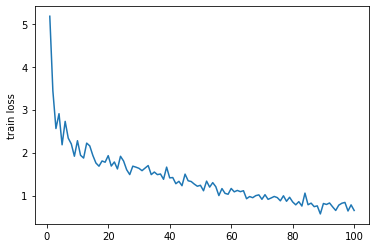

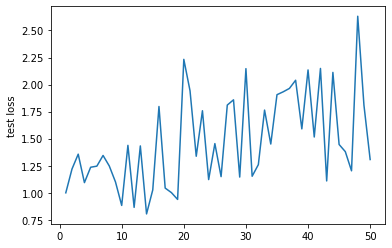

Finished Training


In [15]:
import os
from torch import nn
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
train_test(fusionnet().to(device),50,100)

[1,  100] loss:0.661
[1,  200] loss:0.676
Test set: Average loss: 2.3443
[2,  100] loss:0.825
[2,  200] loss:0.651
Test set: Average loss: 1.2565
[3,  100] loss:0.815
[3,  200] loss:0.716
Test set: Average loss: 1.3649
[4,  100] loss:0.634
[4,  200] loss:0.658
Test set: Average loss: 1.8647
[5,  100] loss:0.630
[5,  200] loss:0.703
Test set: Average loss: 1.5309
[6,  100] loss:0.702
[6,  200] loss:0.625
Test set: Average loss: 1.3852
[7,  100] loss:0.767
[7,  200] loss:0.733
Test set: Average loss: 1.3361
[8,  100] loss:0.577
[8,  200] loss:0.689
Test set: Average loss: 1.6555
[9,  100] loss:0.618
[9,  200] loss:0.686
Test set: Average loss: 1.6752
[10,  100] loss:0.641
[10,  200] loss:0.621
Test set: Average loss: 1.4355
[11,  100] loss:0.559
[11,  200] loss:0.601
Test set: Average loss: 2.0808
[12,  100] loss:0.544
[12,  200] loss:0.551
Test set: Average loss: 2.9367
[13,  100] loss:0.578
[13,  200] loss:0.690
Test set: Average loss: 2.0215
[14,  100] loss:0.602
[14,  200] loss:0.605

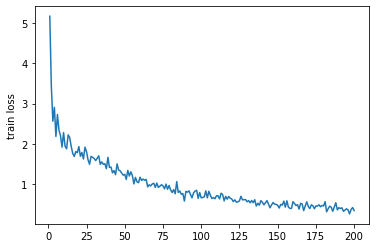

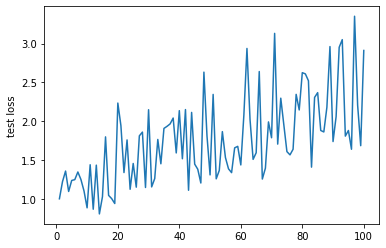

Finished Training


In [16]:
import os
from torch import nn
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
model = torch.load('/content/drive/MyDrive/yoga/models/tree/YogaEvaNet_tree2.pkl')
train_test2(model.to(device),50,100)

[1,  100] loss:0.374
[1,  200] loss:0.427
Test set: Average loss: 2.4604
[2,  100] loss:0.287
[2,  200] loss:0.382
Test set: Average loss: 2.9227
[3,  100] loss:0.291
[3,  200] loss:0.333
Test set: Average loss: 3.3147
[4,  100] loss:0.347
[4,  200] loss:0.345
Test set: Average loss: 1.8309
[5,  100] loss:0.305
[5,  200] loss:0.329
Test set: Average loss: 2.4142
[6,  100] loss:0.311
[6,  200] loss:0.322
Test set: Average loss: 2.1071
[7,  100] loss:0.282
[7,  200] loss:0.393
Test set: Average loss: 2.1552
[8,  100] loss:0.297
[8,  200] loss:0.319
Test set: Average loss: 1.9860
[9,  100] loss:0.242
[9,  200] loss:0.403
Test set: Average loss: 2.2757
[10,  100] loss:0.237
[10,  200] loss:0.396
Test set: Average loss: 1.7836
[11,  100] loss:0.282
[11,  200] loss:0.368
Test set: Average loss: 2.7198
[12,  100] loss:0.293
[12,  200] loss:0.319
Test set: Average loss: 2.8172
[13,  100] loss:0.331
[13,  200] loss:0.314
Test set: Average loss: 1.3880
[14,  100] loss:0.291
[14,  200] loss:0.284

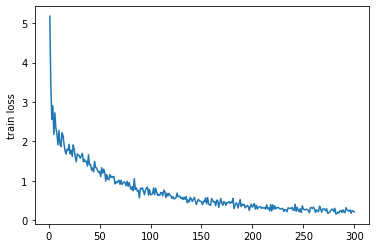

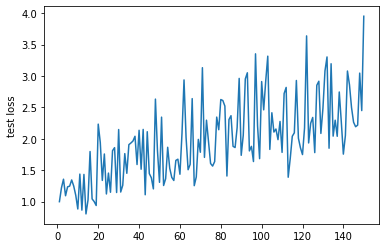

Finished Training


In [17]:
import os
from torch import nn
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
model = torch.load('/content/drive/MyDrive/yoga/models/tree/YogaEvaNet_tree2.pkl')
train_test2(model.to(device),50,100)

[1,  100] loss:0.126
[1,  200] loss:0.241
Test set: Average loss: 3.2284
[2,  100] loss:0.254
[2,  200] loss:0.235
Test set: Average loss: 2.1045
[3,  100] loss:0.243
[3,  200] loss:0.210
Test set: Average loss: 2.5242
[4,  100] loss:0.166
[4,  200] loss:0.382
Test set: Average loss: 2.8039
[5,  100] loss:0.249
[5,  200] loss:0.192
Test set: Average loss: 2.7882
[6,  100] loss:0.239
[6,  200] loss:0.163
Test set: Average loss: 2.6485
[7,  100] loss:0.211
[7,  200] loss:0.308
Test set: Average loss: 3.1080
[8,  100] loss:0.263
[8,  200] loss:0.227
Test set: Average loss: 2.9041
[9,  100] loss:0.158
[9,  200] loss:0.198
Test set: Average loss: 2.9338
[10,  100] loss:0.189
[10,  200] loss:0.210
Test set: Average loss: 2.6884
[11,  100] loss:0.179
[11,  200] loss:0.243
Test set: Average loss: 2.2826
[12,  100] loss:0.300
[12,  200] loss:0.227
Test set: Average loss: 1.9887
[13,  100] loss:0.222
[13,  200] loss:0.200
Test set: Average loss: 2.3037
[14,  100] loss:0.149
[14,  200] loss:0.216

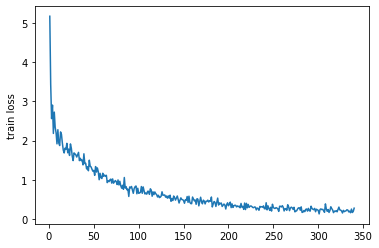

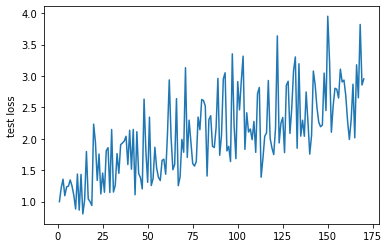

Finished Training


In [28]:
import os
from torch import nn
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
model = torch.load('/content/drive/MyDrive/yoga/models/tree/YogaEvaNet_tree2.pkl')
train_test2(model.to(device),20,100)

[1,  100] loss:0.248
[1,  200] loss:0.186
Test set: Average loss: 2.4574
[2,  100] loss:0.261
[2,  200] loss:0.153
Test set: Average loss: 2.3398
[3,  100] loss:0.214
[3,  200] loss:0.217
Test set: Average loss: 1.9992
[4,  100] loss:0.207
[4,  200] loss:0.210
Test set: Average loss: 2.3051
[5,  100] loss:0.227
[5,  200] loss:0.143
Test set: Average loss: 3.1440
[6,  100] loss:0.188
[6,  200] loss:0.147
Test set: Average loss: 2.8034
[7,  100] loss:0.204
[7,  200] loss:0.163
Test set: Average loss: 2.8786
[8,  100] loss:0.246
[8,  200] loss:0.150
Test set: Average loss: 4.1104
[9,  100] loss:0.223
[9,  200] loss:0.134
Test set: Average loss: 3.9514
[10,  100] loss:0.160
[10,  200] loss:0.146
Test set: Average loss: 2.7671


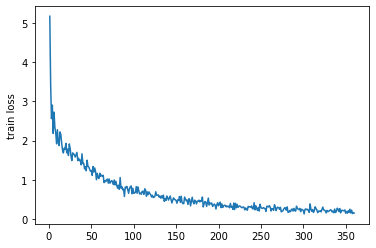

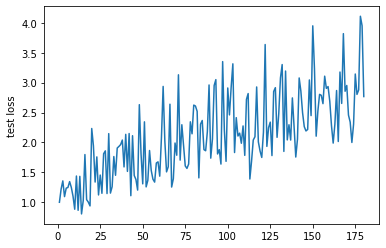

Finished Training


In [29]:
import os
from torch import nn
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
model = torch.load('/content/drive/MyDrive/yoga/models/tree/YogaEvaNet_tree2.pkl')
train_test2(model.to(device),10,100)

[1,  100] loss:0.251
[1,  200] loss:0.148
Test set: Average loss: 3.5732
[2,  100] loss:0.155
[2,  200] loss:0.217
Test set: Average loss: 3.2663
[3,  100] loss:0.156
[3,  200] loss:0.119
Test set: Average loss: 3.5506
[4,  100] loss:0.193
[4,  200] loss:0.213
Test set: Average loss: 3.4491
[5,  100] loss:0.181
[5,  200] loss:0.161
Test set: Average loss: 3.0327
[6,  100] loss:0.199
[6,  200] loss:0.190
Test set: Average loss: 3.1963
[7,  100] loss:0.138
[7,  200] loss:0.164
Test set: Average loss: 2.8845
[8,  100] loss:0.137
[8,  200] loss:0.206
Test set: Average loss: 2.8941
[9,  100] loss:0.223
[9,  200] loss:0.116
Test set: Average loss: 3.4048
[10,  100] loss:0.120
[10,  200] loss:0.214
Test set: Average loss: 2.5552


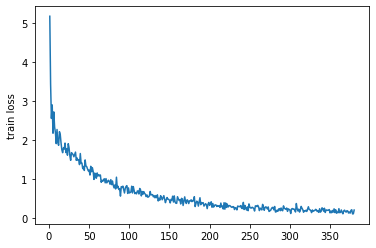

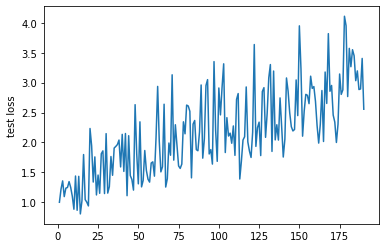

Finished Training


In [43]:
import os
from torch import nn
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
model = torch.load('/content/drive/MyDrive/yoga/models/tree/YogaEvaNet_tree2.pkl')
train_test2(model.to(device),10,100)

[1,  100] loss:0.179
[1,  200] loss:0.195
Test set: Average loss: 2.5604
[2,  100] loss:0.126
[2,  200] loss:0.132
Test set: Average loss: 3.4411
[3,  100] loss:0.152
[3,  200] loss:0.146
Test set: Average loss: 2.9121
[4,  100] loss:0.167
[4,  200] loss:0.179
Test set: Average loss: 3.7903
[5,  100] loss:0.234
[5,  200] loss:0.141
Test set: Average loss: 2.2860
[6,  100] loss:0.155
[6,  200] loss:0.194
Test set: Average loss: 2.9671
[7,  100] loss:0.200
[7,  200] loss:0.167
Test set: Average loss: 3.5868
[8,  100] loss:0.222
[8,  200] loss:0.147
Test set: Average loss: 2.9077
[9,  100] loss:0.156
[9,  200] loss:0.244
Test set: Average loss: 2.2857
[10,  100] loss:0.175
[10,  200] loss:0.152
Test set: Average loss: 3.0856


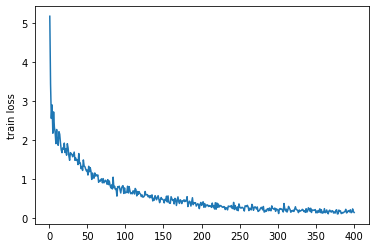

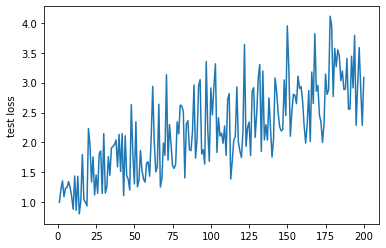

Finished Training


In [44]:
import os
from torch import nn
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
model = torch.load('/content/drive/MyDrive/yoga/models/tree/YogaEvaNet_tree2.pkl')
train_test2(model.to(device),10,100)

In [26]:
#训练150个epoch的测试精度
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
model = torch.load('/content/drive/MyDrive/yoga/models/tree/YogaEvaNet_tree2.pkl')
model.to(device)
print("测试精度如下：")
test(model)

测试精度如下：
测试集精度为：66%
测试集中不标准动作图片的预测精度为：60%
测试集中标准动作图片的预测精度为：71%
混淆矩阵为：
col_0  0.0  1.0
row_0          
0.0     15   10
1.0     11   27
